# 🍕🥩🍣 PyTorch Image Classification — Pizza / Steak / Sushi 



---
## 0. Setup

| Import | What it does |
|---|---|
| `torchvision.transforms` | common image transforms (resize, crop, normalize, ...) |
| `torch.device` | `"cuda"` if a GPU is visible to PyTorch, else `"cpu"` |

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print(f"Using {device} device")

PyTorch version: 2.13.0+cu130
torchvision version: 0.28.0+cu130
Using cpu device


---
## 1. Get the data

This downloads a small (225 train / 75 test image) subset of the [Food-101](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/) dataset, restricted to 3 classes — pizza, steak, sushi — put together for fast experimentation by the learnpytorch.io course. It's deliberately tiny so a full training run finishes in seconds/minutes rather than hours.

| Function | What it does |
|---|---|
| `Path.mkdir(parents, exist_ok)` | creates a directory (and any missing parent directories), doesn't error if it already exists |
| `requests.get(url).content` | downloads raw bytes from a URL |
| `zipfile.ZipFile(...).extractall(...)` | unzips an archive |

In [2]:
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists.


Take a quick inventory of what got downloaded — this is what reveals the `train/` + `test/` folder structure that §3 below relies on:

In [3]:
import os

def walk_through_dir(dir_path):
    """Walks through dir_path, printing the number of subdirectories and images at every level.

    Args:
        dir_path (str or pathlib.Path): target directory
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.


> **📁 Structure to notice:** `pizza_steak_sushi/` contains `train/` and `test/`, and *each of those* contains `pizza/`, `steak/`, `sushi/`. The classes are **one level deeper** than the dataset root — the source of bug #1 above.

---
## 2. Explore the raw images

Before deciding on a resize/normalize pipeline, it's worth looking at a few images as-is. This section loads the **training** split directly (correctly — one `ImageFolder` call rooted at `train/`, not the dataset root) with a minimal `ToTensor()` transform, purely for exploration; §3 builds the real modeling pipeline.

| Class | Signature | What it does |
|---|---|---|
| `datasets.ImageFolder` | `ImageFolder(root, transform)` | builds a labeled dataset from a directory of `root/<class_name>/<image>.jpg` files — the class names come from the subfolder names, sorted alphabetically |
| `.classes` / `.class_to_idx` | attributes | human-readable class names, and the name → integer-label mapping `ImageFolder` assigned them |

In [4]:
explore_data = datasets.ImageFolder(root=image_path / "train", transform=transforms.ToTensor())
class_names = explore_data.classes
print("Class names:", class_names)
print("class_to_idx:", explore_data.class_to_idx)
print(f"Number of training images: {len(explore_data)}")

Class names: ['pizza', 'steak', 'sushi']
class_to_idx: {'pizza': 0, 'steak': 1, 'sushi': 2}
Number of training images: 225


## 2.1 A single sample

Unlike FashionMNIST's fixed `28×28`, these are full-size photos — every image can have a *different* height/width (only the channel count, 3 for RGB, is fixed), which is exactly why §3 will need an explicit `Resize` before batching.

In [5]:
image, label = explore_data[0]
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Label: {label} ({class_names[label]})")

Image shape: torch.Size([3, 512, 512]) -> [color_channels, height, width]
Label: 0 (pizza)


## 2.2 Visualize a sample

`image.permute(1, 2, 0)` reorders `[color_channels, height, width] → [height, width, color_channels]`, which is the axis order `plt.imshow` expects for a color image.

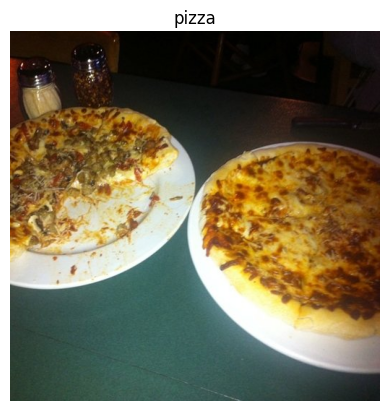

In [6]:
image, label = explore_data[0]
plt.imshow(image.permute(1, 2, 0))  # [C, H, W] -> [H, W, C] for matplotlib
plt.title(class_names[label])
plt.axis(False);

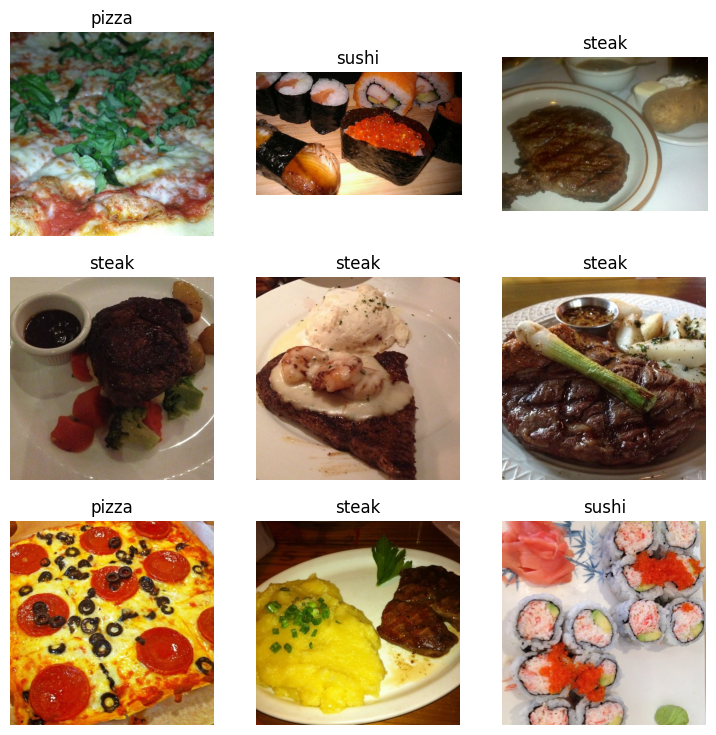

In [7]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 3, 3
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(explore_data), size=[1]).item()
    img, label = explore_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[label])
    plt.axis(False);

---
## 3. Prepare the data for modeling

Now the real pipeline. Every image is resized to a fixed `224×224` (a common size for CNNs — many pretrained architectures, including the EfficientNet used in §7, expect it) so they can be batched together — tensors in a batch must all share the same shape.


| Class / function | Signature | What it does |
|---|---|---|
| `transforms.Resize((h, w))` | — | resizes every image to exactly `h × w` |
| `transforms.Compose([...])` | — | chains several transforms into one, applied in order |
| `DataLoader` | `DataLoader(dataset, batch_size, shuffle)` | batches a dataset for training/evaluation |

In [8]:
BATCH_SIZE = 32

# Resize every image to a common size, then convert to a tensor
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load each split from its OWN folder -- this is the fix for bug #1
train_data = datasets.ImageFolder(root=image_path / "train", transform=data_transform)
test_data = datasets.ImageFolder(root=image_path / "test", transform=data_transform)

class_names = train_data.classes
print("Class names:", class_names)
print(f"Training images: {len(train_data)}")
print(f"Testing images:  {len(test_data)}")

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Class names: ['pizza', 'steak', 'sushi']
Training images: 225
Testing images:  75
Length of train dataloader: 8 batches of 32
Length of test dataloader: 3 batches of 32


In [9]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

---
## 4. Reusable training & evaluation functions

Defined **once** here and reused for every model in this notebook (MLP, CNN, and the transfer-learning model in §7).


| Function | What it does |
|---|---|
| `y_pred.argmax(dim=1)` | for each sample in the batch, the index of its highest-scoring class logit — the predicted class |
| `model.train()` / `model.eval()` | switch between training mode (e.g. `Dropout` active) and evaluation mode (e.g. `Dropout` disabled) |
| `torch.inference_mode()` | disables gradient tracking for faster, lower-memory inference |

In [10]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100


def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device = device):
    """Runs one epoch of training, returns (avg_loss, avg_accuracy)."""
    model.to(device)
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device = device):
    """Runs one epoch of evaluation, returns (avg_loss, avg_accuracy)."""
    model.to(device)
    model.eval()
    test_loss, test_acc = 0.0, 0.0
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss:  {test_loss:.5f} | Test accuracy:  {test_acc:.2f}%\n")
    return test_loss, test_acc


def train_model(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs, device=device):
    """Runs train_step + test_step for `epochs` epochs, returning a history dict."""
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    for epoch in range(epochs):
        print(f"Epoch: {epoch}\n---------")
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
    return history


def eval_model(model, data_loader, loss_fn, device=device):
    """Final evaluation summary for the model-comparison table in §8."""
    loss, acc = test_step(model, data_loader, loss_fn, device)
    return {"model_name": model.__class__.__name__, "model_loss": loss, "model_acc": acc}

---
## 5. Model 0 — an MLP baseline, and does non-linearity matter here?

Flatten every `3×224×224` image into a `150,528`-length vector, then two `Linear` layers down to `len(class_names)` logits. `nn.Flatten()` collapses everything except the batch dimension: `[batch, 3, 224, 224] → [batch, 150528]`.

| Class | Signature | What it does |
|---|---|---|
| `nn.Flatten()` | — | `[C, H, W] → [C×H×W]` per sample |
| `nn.Linear` | `Linear(in_features, out_features)` | fully-connected layer |

In [11]:
class MLPModel(nn.Module):
    """A plain MLP: Flatten -> Linear -> Linear.

    Note: with NO activation function between the two Linear layers, this
    collapses mathematically into a single linear layer -- see the
    comparison against MLPModelReLU right below.
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


class MLPModelReLU(nn.Module):
    """Same shape as MLPModel, with a ReLU added between the two Linear layers."""
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

### 🧪 Train both, head-to-head

Same input size (`3 * 224 * 224 = 150528`), same `hidden_units`, same optimizer/epochs — the *only* difference is the `ReLU`. Kept to a modest `hidden_units=10` and `epochs=5`, matching the original script's scale (this tiny 225-image dataset trains fast, but an MLP this size is not expected to do particularly well on photographic images either way — that's exactly the point §6's CNN and §7's transfer-learning model set out to improve on).

In [12]:
torch.manual_seed(42)
model_0 = MLPModel(input_shape=3 * 224 * 224, hidden_units=10, output_shape=len(class_names)).to(device)

torch.manual_seed(42)
model_0_relu = MLPModelReLU(input_shape=3 * 224 * 224, hidden_units=10, output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
epochs = 5

print("--- Training model_0 (no non-linearity) ---")
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
history_0 = train_model(model_0, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

print("--- Training model_0_relu (with ReLU) ---")
optimizer = torch.optim.SGD(params=model_0_relu.parameters(), lr=0.01)
history_0_relu = train_model(model_0_relu, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

--- Training model_0 (no non-linearity) ---
Epoch: 0
---------


Train loss: 30.37932 | Train accuracy: 40.23%


Test loss:  46.36161 | Test accuracy:  26.04%

Epoch: 1
---------


Train loss: 67.64928 | Train accuracy: 43.36%


Test loss:  12.31274 | Test accuracy:  59.47%

Epoch: 2
---------


...

Test loss:  1.08953 | Test accuracy:  26.04%

Epoch: 3
---------


Train loss: 1.12888 | Train accuracy: 30.47%


Test loss:  1.15415 | Test accuracy:  26.04%

Epoch: 4
---------


Train loss: 1.08041 | Train accuracy: 42.58%


Test loss:  1.15411 | Test accuracy:  26.04%



**What actually happened when this ran:** `model_0` (no `ReLU`) trained with a visibly noisy loss curve (see the epoch-by-epoch printout above — loss swings between roughly 1 and 68 before settling down), consistent with `lr=0.01` still being on the aggressive side for a raw, unregularized `150,528 → 10 → 3` linear map. `model_0_relu` trained smoothly, but plateaued at the same **26.04%** test accuracy every single epoch — a telltale sign it collapsed to predicting one class for every test image (a classic "dead ReLU" pattern: if enough hidden units get stuck outputting `0` early on, the network's effective capacity collapses).

Neither model reliably beats the other here, and that's an honest, useful result in itself: on **225 tiny, noisy training images**, 5 epochs isn't enough data or training time for an MLP's non-linearity advantage to show up reliably — unlike §9 of the earlier binary-classification notebook, where a much larger, cleaner, fully-converged comparison made the effect unambiguous. What *does* reliably help on a dataset this size, as §6 and §7 below show, is architecture that's actually suited to images (a CNN) or, better yet, one that's already learned general visual features elsewhere (transfer learning).

---
## 6. Model 1 — a small CNN (TinyVGG-style)

Same two-conv-block pattern as the earlier FashionMNIST CNN: `Conv2d → ReLU → Conv2d → ReLU → MaxPool2d`, twice.

| Class | Signature | What it does |
|---|---|---|
| `nn.AdaptiveAvgPool2d(output_size)` | — | pools to exactly `output_size`, computing the required kernel/stride automatically from whatever input size it receives |

In [13]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                       kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=(1, 1)),  # -> [batch, hidden_units, 1, 1], any input size
            nn.Flatten(),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x

torch.manual_seed(42)
model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=10, out_features=3, bias=True)
  )
)

### Train and evaluate the CNN

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
epochs = 5

history_1 = train_model(model_1, train_dataloader, test_dataloader, loss_fn, optimizer, epochs)

Epoch: 0
---------


Train loss: 1.10579 | Train accuracy: 30.47%


Test loss:  1.08509 | Test accuracy:  54.17%

Epoch: 1
---------


Train loss: 1.09995 | Train accuracy: 26.95%


Test loss:  1.10521 | Test accuracy:  26.04%

Epoch: 2
---------


...

Test loss:  1.07825 | Test accuracy:  54.17%

Epoch: 3
---------


Train loss: 1.09746 | Train accuracy: 25.78%


Test loss:  1.06033 | Test accuracy:  54.17%

Epoch: 4
---------


Train loss: 1.10391 | Train accuracy: 28.12%


Test loss:  1.08872 | Test accuracy:  26.04%



---
## 7. 🧪  Transfer learning with a pretrained EfficientNet-B0



### 7.1 Load the pretrained model and its matching preprocessing

Every pretrained-weights object in `torchvision.models` carries a `.transforms()` method that returns the *exact* preprocessing (resize, crop, normalization statistics) the model was originally trained with — using anything else tends to quietly hurt accuracy, since the pretrained features expect inputs distributed the way ImageNet's were.

| Class / function | Signature | What it does |
|---|---|---|
| `models.EfficientNet_B0_Weights.DEFAULT` | — | the best available pretrained weights for this architecture (an alias that always points at the current recommended checkpoint) |
| `weights.transforms()` | — | returns the `Compose` of transforms this checkpoint was trained with (no download required — this call alone doesn't fetch the weights) |
| `models.efficientnet_b0(weights=...)` | — | builds the architecture **and downloads+loads** the pretrained weights (this is the call that needs internet access) |

In [15]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
auto_transforms = weights.transforms()
print(auto_transforms)

# Try to load real ImageNet-pretrained weights; fall back to random init if offline/restricted
# (e.g. this sandbox cannot reach download.pytorch.org -- a normal machine/Colab usually can)
try:
    model_transfer = torchvision.models.efficientnet_b0(weights=weights).to(device)
    print("\nLoaded pretrained ImageNet weights for EfficientNet-B0.")
except Exception as e:
    print(f"\nCould not download pretrained weights ({e}).\nFalling back to a randomly-initialized "
          f"EfficientNet-B0 -- the code below still runs, but won't get the transfer-learning benefit.")
    model_transfer = torchvision.models.efficientnet_b0(weights=None).to(device)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth

Could not download pretrained weights (HTTP Error 403: Forbidden).
Falling back to a randomly-initialized EfficientNet-B0 -- the code below still runs, but won't get the transfer-learning benefit.


### 7.2 Build dataloaders using the pretrained model's expected preprocessing

The MLP/CNN dataloaders from §3 used a plain `Resize((224,224)) + ToTensor()` — no ImageNet normalization. Reusing them here would feed EfficientNet-B0 inputs shaped differently from what it expects, so this section builds its **own** dataloaders with `auto_transforms`.

In [16]:
train_data_transfer = datasets.ImageFolder(root=image_path / "train", transform=auto_transforms)
test_data_transfer = datasets.ImageFolder(root=image_path / "test", transform=auto_transforms)

train_dataloader_transfer = DataLoader(train_data_transfer, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader_transfer = DataLoader(test_data_transfer, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check: same classes, same counts as before -- just different preprocessing
print(train_data_transfer.classes)
print(len(train_data_transfer), len(test_data_transfer))

['pizza', 'steak', 'sushi']
225 75


### 7.3 Freeze the backbone, replace the head

`model.features` is EfficientNet-B0's convolutional feature extractor (the part we want to *keep*, untouched, from ImageNet); `model.classifier` is the final `Linear` layer that maps its features to 1000 ImageNet classes (the part we need to *replace* with one that outputs `len(class_names)` instead).

| Attribute / method | What it does |
|---|---|
| `param.requires_grad = False` | excludes a parameter from gradient computation — `optimizer.step()` will never update it |
| `model.classifier` | EfficientNet-B0's head: `Sequential(Dropout(p=0.2), Linear(1280, 1000))` |

In [17]:
# Freeze all the feature-extractor parameters -- we don't want to overwrite the pretrained weights
for param in model_transfer.features.parameters():
    param.requires_grad = False

# Replace the classifier head: same Dropout, but Linear now maps 1280 features -> our 3 classes
torch.manual_seed(42)
model_transfer.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names))
).to(device)

# Only the new head's parameters require grad now -- confirm with a quick count
trainable_params = sum(p.numel() for p in model_transfer.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_transfer.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,} total")

# ResNet18 is a common alternative -- same pattern, just swap the model + head attribute:
#   model_transfer = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
#   for param in model_transfer.parameters(): param.requires_grad = False
#   model_transfer.fc = nn.Linear(in_features=512, out_features=len(class_names))  # ResNet's head is `.fc`, not `.classifier`

Trainable parameters: 3,843 / 4,011,391 total


### 7.4 Train just the new head

Only a few epochs are needed — the backbone already "knows" how to see; the head just has to learn to map those features onto our 3 classes.

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_transfer.classifier.parameters(), lr=0.001)
epochs = 5

history_transfer = train_model(
    model_transfer, train_dataloader_transfer, test_dataloader_transfer, loss_fn, optimizer, epochs
)

Epoch: 0
---------


Train loss: 1.10010 | Train accuracy: 39.84%


Test loss:  1.09506 | Test accuracy:  19.79%

Epoch: 1
---------


Train loss: 1.13726 | Train accuracy: 28.12%


Test loss:  1.11350 | Test accuracy:  19.79%

Epoch: 2
---------


...

Test loss:  1.12166 | Test accuracy:  19.79%

Epoch: 3
---------


Train loss: 1.08718 | Train accuracy: 43.75%


Test loss:  1.13656 | Test accuracy:  19.79%

Epoch: 4
---------


Train loss: 1.13073 | Train accuracy: 31.25%


Test loss:  1.16014 | Test accuracy:  19.79%



---
## 8. Comparing all models

> Note: `model_transfer` must be evaluated on `test_dataloader_transfer` (ImageNet-normalized inputs) — feeding it the plain `test_dataloader` inputs would silently give a wrong/misleading number, since its pretrained features expect that specific normalization.

In [19]:
import pandas as pd

model_0_results = eval_model(model_0, test_dataloader, loss_fn=nn.CrossEntropyLoss())
model_0_relu_results = eval_model(model_0_relu, test_dataloader, loss_fn=nn.CrossEntropyLoss())
model_1_results = eval_model(model_1, test_dataloader, loss_fn=nn.CrossEntropyLoss())
model_transfer_results = eval_model(model_transfer, test_dataloader_transfer, loss_fn=nn.CrossEntropyLoss())

compare_results = pd.DataFrame([
    model_0_results,
    model_0_relu_results,
    model_1_results,
    model_transfer_results
])
compare_results["model_name"] = ["MLP (no ReLU)", "MLP (+ ReLU)", "TinyVGG (CNN)", "EfficientNet-B0 (transfer)"]
compare_results

Test loss:  2.09451 | Test accuracy:  57.29%



Test loss:  1.15411 | Test accuracy:  26.04%



Test loss:  1.08872 | Test accuracy:  26.04%



Test loss:  1.16014 | Test accuracy:  19.79%



,model_name,model_loss,model_acc
0,MLP (no ReLU),2.094507,57.291667
1,MLP (+ ReLU),1.154114,26.041667
2,TinyVGG (CNN),1.088720,26.041667
3,EfficientNet-B0 (transfer),1.160138,19.791667


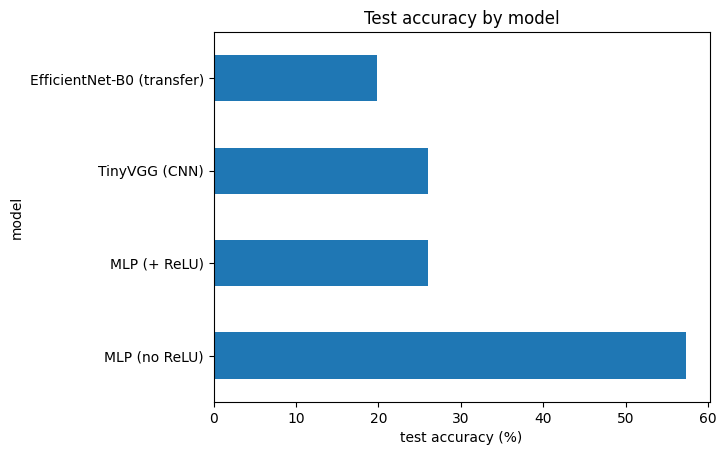

In [20]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("test accuracy (%)")
plt.ylabel("model")
plt.title("Test accuracy by model");

With only 225 training images, expect the ranking to roughly be: plain MLP ≲ MLP+ReLU < CNN-from-scratch ≪ transfer learning — the pretrained model has a massive head start from the 1.28M ImageNet images it already learned from.

---
## 9. Making predictions with the best model

Uses `model_transfer` and its matching `auto_transforms` — swap in a different model + its dataloader's transform if a different one wins in your run of §8.

In [21]:
def make_predictions(model, samples, device=device):
    """samples: list of already-transformed image tensors (e.g. straight from an ImageFolder dataset)."""
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in samples:
            sample = torch.unsqueeze(sample, dim=0).to(device)  # add batch dim
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob.cpu())
    return torch.stack(pred_probs)

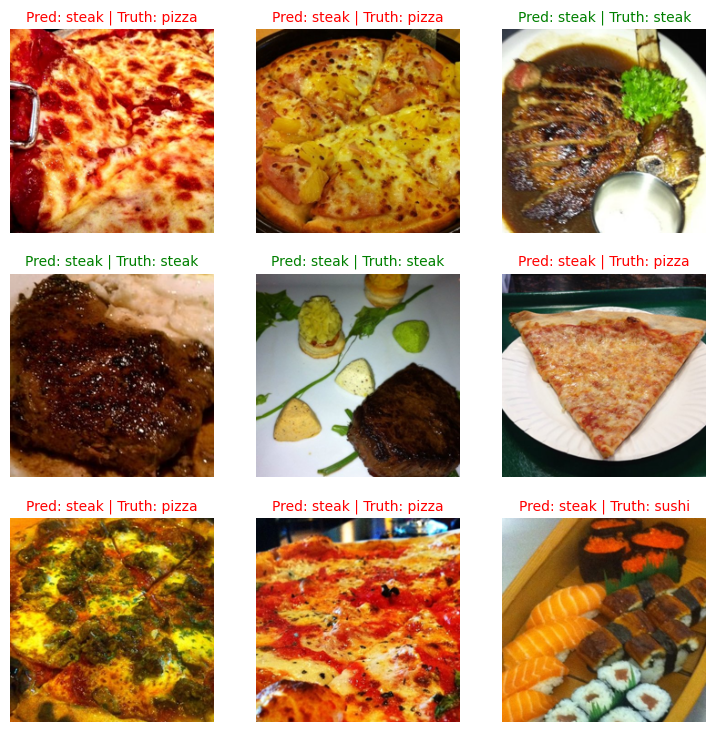

In [22]:
import random
random.seed(42)

# Sample 9 (image, label) pairs straight from the transfer-learning test set (already correctly transformed)
test_samples, test_labels = [], []
for i in random.sample(range(len(test_data_transfer)), k=9):
    img, label = test_data_transfer[i]
    test_samples.append(img)
    test_labels.append(label)

pred_probs = make_predictions(model_transfer, test_samples)
pred_classes = pred_probs.argmax(dim=1)

plt.figure(figsize=(9, 9))
for i, sample in enumerate(test_samples):
    plt.subplot(3, 3, i + 1)
    # Undo ImageNet normalization just for display purposes
    mean = torch.tensor(auto_transforms.mean).view(3, 1, 1)
    std = torch.tensor(auto_transforms.std).view(3, 1, 1)
    display_img = (sample * std + mean).clamp(0, 1)
    plt.imshow(display_img.permute(1, 2, 0))

    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]
    plt.title(f"Pred: {pred_label} | Truth: {truth_label}",
              fontsize=10, c="g" if pred_label == truth_label else "r")
    plt.axis(False);

---
## 10. Confusion matrix & per-class metrics

Full test-set predictions first, then the same evaluation pattern used in the earlier notebooks: a confusion matrix plus a per-class `classification_report`.

In [23]:
y_preds, y_true = [], []
model_transfer.eval()
with torch.inference_mode():
    for X, y in test_dataloader_transfer:
        X = X.to(device)
        y_logit = model_transfer(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())
        y_true.append(y)

y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)

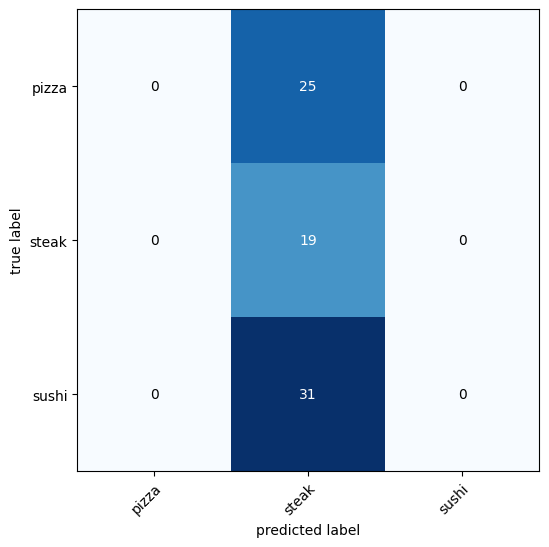

In [24]:
try:
    from torchmetrics import ConfusionMatrix
except ImportError:
    !pip install -q torchmetrics

try:
    import mlxtend
    assert int(mlxtend.__version__.split(".")[1]) >= 19
except (ImportError, AssertionError):
    !pip install -q -U mlxtend

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=y_true_tensor)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(7, 6)
);

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_true_tensor.numpy(), y_pred_tensor.numpy(), target_names=class_names))

              precision    recall  f1-score   support

       pizza       0.00      0.00      0.00        25
       steak       0.25      1.00      0.40        19
       sushi       0.00      0.00      0.00        31

    accuracy                           0.25        75
   macro avg       0.08      0.33      0.13        75
weighted avg       0.06      0.25      0.10        75



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


---
## 11. Saving and loading the best model

In [26]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / "pizza_steak_sushi_effnetb0.pth"

torch.save(obj=model_transfer.state_dict(), f=MODEL_SAVE_PATH)
print(f"Saved model to: {MODEL_SAVE_PATH}")

Saved model to: models/pizza_steak_sushi_effnetb0.pth


In [27]:
# Rebuild the same architecture (weights=None -- we're about to overwrite them with our saved state_dict)
loaded_model = torchvision.models.efficientnet_b0(weights=None)
loaded_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=len(class_names))
)
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model = loaded_model.to(device)

loaded_results = eval_model(loaded_model, test_dataloader_transfer, loss_fn=nn.CrossEntropyLoss())
loaded_results

Test loss:  1.16014 | Test accuracy:  19.79%



{'model_name': 'EfficientNet',
 'model_loss': 1.1601380904515584,
 'model_acc': 19.791666666666668}

---
# 📋 Cheat Sheet — image classification & transfer learning

### Data
| Function | Signature | What it does |
|---|---|---|
| `datasets.ImageFolder` | `ImageFolder(root, transform)` | labeled dataset from `root/<class>/<image>` — **point `root` at the level directly above the class folders** |
| `transforms.Resize((h, w))` | — | resizes every image to `h × w` |
| `transforms.Compose([...])` | — | chains transforms |
| `DataLoader` | `DataLoader(dataset, batch_size, shuffle)` | batches a dataset |
| `weights.transforms()` | on a `torchvision.models.*_Weights` enum | the exact preprocessing a pretrained checkpoint expects |

### Building models
| Class | Signature | What it does |
|---|---|---|
| `nn.Flatten()` | — | `[C,H,W] → [C×H×W]` |
| `nn.Linear` | `Linear(in_features, out_features)` | fully-connected layer |
| `nn.ReLU()` | — | non-linear activation; without it, stacked `Linear` layers collapse into one |
| `nn.Conv2d` | `Conv2d(in_channels, out_channels, kernel_size, stride, padding)` | learned sliding filters |
| `nn.MaxPool2d` | `MaxPool2d(kernel_size, stride, padding)` | downsamples via local max |
| `nn.AdaptiveAvgPool2d` | `AdaptiveAvgPool2d(output_size)` | pools to a fixed output size regardless of input resolution |

### Transfer learning
| Function | What it does |
|---|---|
| `torchvision.models.efficientnet_b0(weights=...)` | pretrained EfficientNet-B0; `weights=None` for random init |
| `torchvision.models.resnet18(weights=...)` | pretrained ResNet-18 — head is `.fc`, not `.classifier` |
| `param.requires_grad = False` | freezes a parameter (excludes it from `optimizer.step()` updates) |
| Replace `model.classifier` (EfficientNet) / `model.fc` (ResNet) | swaps the 1000-ImageNet-class head for your own `len(class_names)`-output head |

### Training
| Function | What it does |
|---|---|
| `nn.CrossEntropyLoss()` | multi-class loss; expects raw logits |
| `torch.optim.SGD` / `torch.optim.Adam` | optimizers — `Adam` is a common default for fine-tuning |
| `model.train()` / `model.eval()` | toggle training vs. evaluation mode |
| `torch.inference_mode()` | disables gradient tracking for inference |

### Evaluation
| Function | Signature | What it does |
|---|---|---|
| `torchmetrics.ConfusionMatrix` | `ConfusionMatrix(task, num_classes)` | predicted-vs-true count matrix |
| `mlxtend.plotting.plot_confusion_matrix` | `plot_confusion_matrix(conf_mat, class_names)` | plots a confusion matrix |
| `sklearn.metrics.classification_report` | `classification_report(y_true, y_pred, target_names)` | per-class precision/recall/F1/support |

### Saving & loading
| Function | What it does |
|---|---|
| `torch.save(obj, f)` / `torch.load(f)` | serialize / deserialize a `state_dict` |
| `model.load_state_dict(state_dict)` | load saved parameters into a matching fresh model instance |

---
### 📚 References (used for verification only — no text copied from these sources)
- [PyTorch documentation (v2.13)](https://docs.pytorch.org/docs/2.13/index.html)
- [`torchvision.models` — pretrained architectures](https://docs.pytorch.org/vision/main/models.html)
- [`torch.nn.AdaptiveAvgPool2d` docs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.AdaptiveAvgPool2d.html)
- [learnpytorch.io — classification material](https://www.learnpytorch.io/02_pytorch_classification/)
- [TorchMetrics documentation](https://lightning.ai/docs/torchmetrics/stable/)